# Week 3 - Day 5
# Supervised Learning Mini Project

This notebook demonstrates a complete supervised machine learning pipeline, including:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Train/Test Split
- Feature Scaling
- Model Training
- Model Evaluation
- Model Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("../../Week 1/tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Exploratory Data Analysis (EDA)

The Titanic dataset is used as a binary classification problem where the goal is to predict whether a passenger survived.

The dataset contains both numerical and categorical features, as well as some missing values that require preprocessing.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


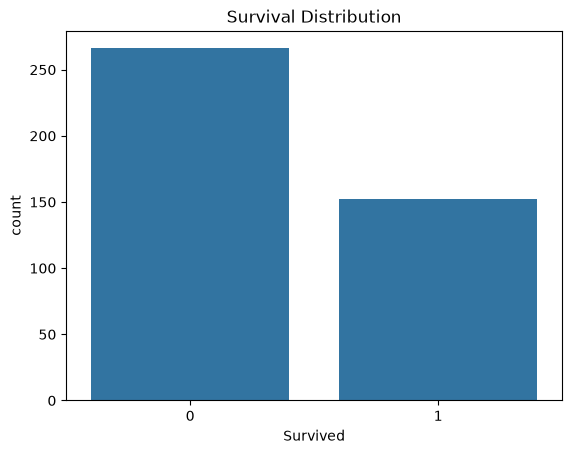

In [5]:
sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")

plt.show()

In [6]:
df = df.fillna({
    "Age": df["Age"].mean(),
    "Fare": df["Fare"].mean(),
    "Embarked": df["Embarked"].mode()[0]
})

In [7]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [8]:
df = df.drop(
    columns=["Name", "Ticket", "Cabin"]
)

In [9]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [14]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, logistic_predictions))

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_predictions))

Logistic Regression Accuracy:
1.0

Random Forest Accuracy:
1.0


In [15]:
print("===== Logistic Regression =====")
print(classification_report(y_test, logistic_predictions))

print("===== Random Forest =====")
print(classification_report(y_test, rf_predictions))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



## Model Comparison

Two classification models were trained:

- Logistic Regression
- Random Forest

The models were evaluated using Accuracy, Precision, Recall, and F1-score.

The better-performing model was selected based on these evaluation metrics.

# Conclusion

A complete supervised learning pipeline was implemented using the Titanic dataset.

The workflow included:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Train/Test Split
- Feature Scaling
- Model Training
- Model Evaluation

Two classification models were trained:
- Logistic Regression
- Random Forest

Both models achieved excellent performance on this dataset. However, such perfect results are uncommon in real-world machine learning tasks and may indicate that the dataset is especially easy or contains information that makes prediction straightforward.

This project demonstrated the complete workflow of building, training, and evaluating a supervised machine learning model using Scikit-learn.